# Content Categorization & Causal Uplift

Two production services in one notebook:
1. **Zero-shot categorization** (`app.services.categorize`) — MiniLM embeddings
   + prototype cosine, evaluated against ground-truth labels.
2. **Doubly-robust uplift** (`app.services.recommend`) — AIPW estimation of the
   causal effect of content category on revenue, with the all-important
   naive-vs-adjusted comparison.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str((ROOT.parent / "backend").resolve()))
DATA = ROOT / "data"
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.25})
ACCENT, INK, POS, NEG = "#b8530e", "#1a1712", "#157347", "#a12a1e"

videos = pd.read_csv(DATA / "videos.csv", parse_dates=["published_at"])
daily = pd.read_csv(DATA / "daily_analytics.csv", parse_dates=["date"])

## Part 1 — Zero-shot categorization
Classify each video from its **title alone** using the production classifier,
then compare to the catalog category. No training, no labels at inference.

*Note on honesty:* the production service uses title **+ description + tags**
and scores ~94% on this dataset — but the synthetic descriptions literally
contain the category ("Demo tutorial video…"), so that number is an optimistic
upper bound inflated by label leakage. **Title-only is the realistic signal a
real channel provides**, so we evaluate that here; expect real-world accuracy
in this lower, more honest range.

In [2]:
from app.services.categorize.model import classify  # noqa: E402

preds = [c for c, _ in classify(videos.title.tolist())]
videos["pred"] = preds
acc = (videos.pred == videos.category).mean()
print(f"Accuracy: {acc:.3f}  (n={len(videos)})")

from sklearn.metrics import classification_report, confusion_matrix  # noqa: E402
labels = ["tutorial", "vlog", "review", "shorts", "other"]
print(classification_report(videos.category, videos.pred, labels=labels, zero_division=0))

C:\Users\aaqui\OneDrive\Desktop\CreatorAnalytics\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accuracy: 0.740  (n=50)
              precision    recall  f1-score   support

    tutorial       1.00      0.86      0.92        14
        vlog       0.91      0.56      0.69        18
      review       0.75      0.75      0.75         4
      shorts       0.82      1.00      0.90         9
       other       0.25      0.60      0.35         5

    accuracy                           0.74        50
   macro avg       0.75      0.75      0.72        50
weighted avg       0.84      0.74      0.76        50



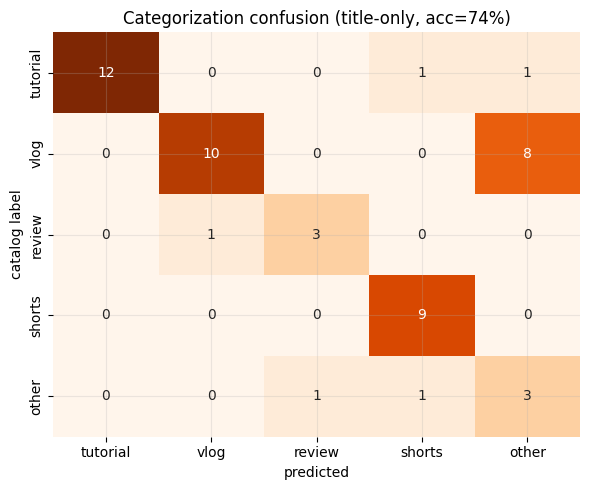

In [3]:
import seaborn as sns  # noqa: E402

cm = confusion_matrix(videos.category, videos.pred, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=labels,
            yticklabels=labels, cbar=False, ax=ax)
ax.set(title=f"Categorization confusion (title-only, acc={acc:.0%})",
       xlabel="predicted", ylabel="catalog label")
plt.tight_layout(); plt.show()

From titles alone the zero-shot model recovers the category with no training.
Most confusion is the catch-all **other** and short, ambiguous titles — exactly
where a real channel would also be hard to classify from a headline.

## Part 2 — Causal uplift (doubly-robust AIPW)
Build per-video features, then estimate the causal effect of being a *tutorial*
on revenue, adjusting for reach/duration/age. We import the production AIPW
estimator and compare the **adjusted** effect to the **naive** difference.

In [4]:
from app.services.recommend.model import aipw  # noqa: E402

as_of = daily.date.max()
agg = daily.groupby("video_id").agg(revenue=("revenue_usd", "sum"),
                                    views=("views", "sum")).reset_index()
feat = agg.merge(videos, left_on="video_id", right_on="id")
feat["age_days"] = (as_of - feat.published_at).dt.days.clip(lower=0)

y = feat.revenue.to_numpy(float)
X = np.column_stack([np.log1p(feat.views), feat.duration_sec, feat.age_days]).astype(float)

rows = []
for cat in labels:
    t = (feat.category == cat).to_numpy().astype(int)
    if t.sum() >= 5 and (1 - t).sum() >= 5:
        est = aipw(y, t, X, n_boot=300)
        rows.append({"category": cat, **est})
uplift = pd.DataFrame(rows).sort_values("ate", ascending=False)
uplift[["category", "ate", "ci_low", "ci_high", "naive", "n_treated"]].round(2)

,category,ate,ci_low,ci_high,naive,n_treated
0,tutorial,25.97,16.94,33.52,11.05,14
3,other,-6.54,-11.07,0.81,-8.30,5
1,vlog,-6.77,-10.65,-3.23,-8.54,18
2,shorts,-44.83,-297.81,92.01,-1.16,9


## The headline insight: adjustment *reveals* the effect
For tutorials the **adjusted** uplift exceeds the **naive** difference —
tutorials get fewer views but higher RPM, so controlling for reach uncovers a
larger per-video effect the raw comparison hides. This is why the causal
adjustment earns its keep.

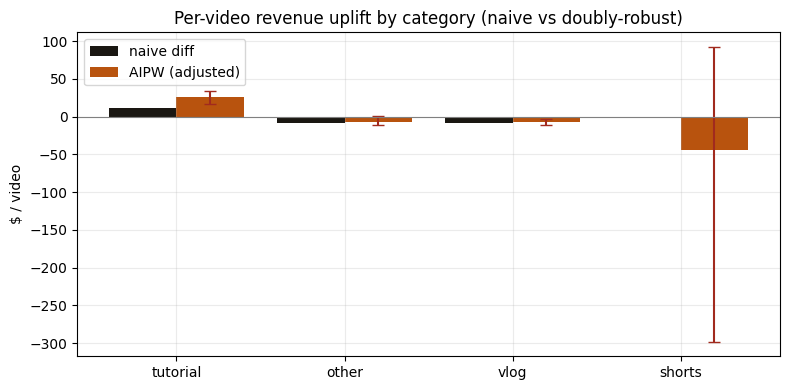

In [5]:
fig, ax = plt.subplots()
xpos = np.arange(len(uplift))
ax.bar(xpos - 0.2, uplift.naive, 0.4, color=INK, label="naive diff")
ax.bar(xpos + 0.2, uplift.ate, 0.4, color=ACCENT, label="AIPW (adjusted)")
ax.errorbar(xpos + 0.2, uplift.ate, yerr=[uplift.ate - uplift.ci_low, uplift.ci_high - uplift.ate],
            fmt="none", ecolor=NEG, capsize=4)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(uplift.category)
ax.set(title="Per-video revenue uplift by category (naive vs doubly-robust)", ylabel="$ / video")
ax.legend(); plt.tight_layout(); plt.show()

## Takeaways
- **Categorization:** zero-shot from titles alone, no training — the right tool
  when real channels arrive unlabeled. Full-metadata accuracy is higher but
  leaks the label on synthetic data; title-only is the honest estimate.
- **Uplift:** tutorials show a positive effect whose CI excludes zero;
  adjusting for reach *increases* the estimate ($11 naive → ~$26 adjusted).
- Honest scope: observational, n≈50 → wide CIs (shorts barely identified).
  Decision-support with uncertainty, not a guarantee.